# Traffic Sensor Analysis

## Importing Libraries


In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
from rapidfuzz import process

## LOAD DATASETS

In [7]:
df = pd.read_csv('traffic_sensor_data.csv')

### Copy Dataset 

In [8]:
sensor_df = df.copy()

## Basic Inspection

In [9]:
sensor_df.head()

,sensor_id,junction_name,congestion_level,avg_wait_time,signal_cycles,accident_reported,roadwork_flag
0,S1,Dadar Circle,High,23.3,9,Yes,Yes
1,S2,Airport Junction,Low,44.2,5,No,No
2,S3,Dadar Circle,Medium,109.9,10,No,Yes
3,S4,Airport Junction,low,108.9,4,No,No
4,S5,Cyber Hub,HIGH,108.5,10,No,No


In [10]:
sensor_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 7 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   sensor_id          100000 non-null  str    
 1   junction_name      100000 non-null  str    
 2   congestion_level   100000 non-null  str    
 3   avg_wait_time      100000 non-null  float64
 4   signal_cycles      100000 non-null  int64  
 5   accident_reported  100000 non-null  str    
 6   roadwork_flag      100000 non-null  str    
dtypes: float64(1), int64(1), str(5)
memory usage: 5.3 MB


In [21]:
sensor_df.shape

(100000, 7)

In [24]:
sensor_df.describe()

,avg_wait_time,signal_cycles
count,100000.000000,100000.000000
mean,62.924938,10.489390
std,35.923829,5.779696
min,5.000000,1.000000
25%,33.800000,5.000000
50%,62.700000,10.000000
75%,91.300000,16.000000
max,500.000000,20.000000


### Checking Missing Values

In [12]:
sensor_df.isnull().sum()

sensor_id            0
junction_name        0
congestion_level     0
avg_wait_time        0
signal_cycles        0
accident_reported    0
roadwork_flag        0
dtype: int64

### STEP 4 - Standardize Text Columns

### Before Cleaning

In [20]:
sensor_df["congestion_level"].value_counts()

congestion_level
Low       40050
High      39909
Medium    20041
Name: count, dtype: int64

### Clean Text Formatting 

In [19]:
valid_levels = ["Low", "Medium", "High"]

def correct_congestion_level(value):

    match = process.extractOne(value, valid_levels)

    return match[0] 


sensor_df["congestion_level"] = sensor_df["congestion_level"].apply(correct_congestion_level)

### Step-6 Check Duplicate Rows

In [22]:
sensor_df.duplicated().sum()

np.int64(0)

### Step-7 Validate Numeric Columns

### Check Wait Time 

In [23]:
sensor_df["avg_wait_time"].describe()

count    100000.000000
mean         62.924938
std          35.923829
min           5.000000
25%          33.800000
50%          62.700000
75%          91.300000
max         500.000000
Name: avg_wait_time, dtype: float64

### STEP 8 — Detect Wait Time Outliers

In [25]:
Q1 = sensor_df["avg_wait_time"].quantile(0.25)

Q3 = sensor_df["avg_wait_time"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR

upper_bound = Q3 + 1.5 * IQR

### Create Outlier Flag 

In [26]:
sensor_df["wait_time_outlier_flag"] = np.where(
    (
        sensor_df["avg_wait_time"] < lower_bound
    ) | 
    (
        sensor_df["avg_wait_time"] > upper_bound
    ),
    1,
    0
    )


### STEP 9 — Visualize Outliers

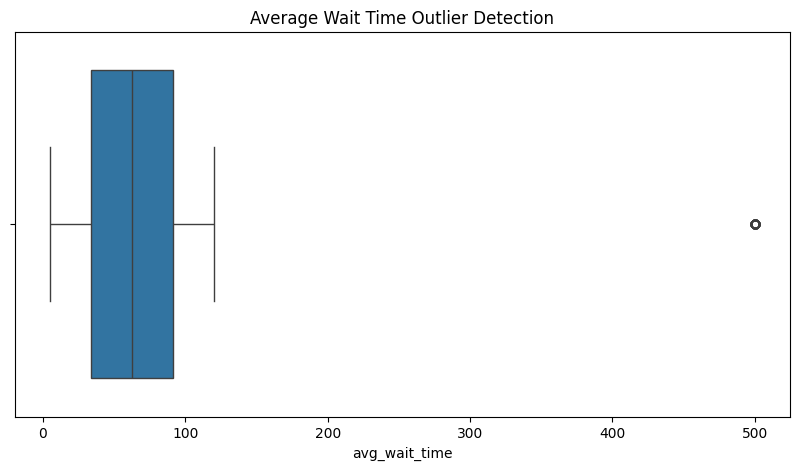

In [27]:
plt.figure(figsize=(10,5))

sns.boxplot(
    x=sensor_df["avg_wait_time"]
)

plt.title("Average Wait Time Outlier Detection")

plt.show()

### STEP 10 — Feature Engineering

### Create Traffic Severity Score

In [28]:
sensor_df["traffic_severity_score"] = (
    sensor_df["wait_time_outlier_flag"]
    +
    np.where(sensor_df["accident_reported"] == "Yes", 1, 0)
    +
    np.where(sensor_df["roadwork_flag"] == "Yes", 1, 0)
)

### STEP 11 — Final Validation

In [29]:
sensor_df.isnull().sum()

sensor_id                 0
junction_name             0
congestion_level          0
avg_wait_time             0
signal_cycles             0
accident_reported         0
roadwork_flag             0
wait_time_outlier_flag    0
traffic_severity_score    0
dtype: int64

In [30]:
sensor_df.describe()

,avg_wait_time,signal_cycles,wait_time_outlier_flag,traffic_severity_score
count,100000.000000,100000.000000,100000.000000,100000.000000
mean,62.924938,10.489390,0.000990,1.004120
std,35.923829,5.779696,0.031449,0.708539
min,5.000000,1.000000,0.000000,0.000000
25%,33.800000,5.000000,0.000000,1.000000
50%,62.700000,10.000000,0.000000,1.000000
75%,91.300000,16.000000,0.000000,2.000000
max,500.000000,20.000000,1.000000,3.000000


In [31]:
sensor_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   sensor_id               100000 non-null  str    
 1   junction_name           100000 non-null  str    
 2   congestion_level        100000 non-null  str    
 3   avg_wait_time           100000 non-null  float64
 4   signal_cycles           100000 non-null  int64  
 5   accident_reported       100000 non-null  str    
 6   roadwork_flag           100000 non-null  str    
 7   wait_time_outlier_flag  100000 non-null  int64  
 8   traffic_severity_score  100000 non-null  int64  
dtypes: float64(1), int64(3), str(5)
memory usage: 6.9 MB


In [32]:
sensor_df.to_csv(
    "cleaned_sensor_dimension.csv",
    index=False
)